<a href="https://colab.research.google.com/github/akshatha9628/IPO-Payments/blob/main/IPO_Payment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title
Analysis of Government Finance Expenditure Data (IPO Payments 2026)


# Domain

Finance

# Objective

1. The primary objective of this project is to analyze government expenditure data and derive meaningful insights into spending patterns, supplier payments, and expense categories to improve financial transparency and decision-making.
2. Understand the structure of government payment data.
3. Clean and preprocess the dataset.
4. Analyze expenditure across different expense types and areas.
5. Identify top suppliers receiving payments.
6. Study monthly spending trends.
7. Generate insights through visualizations and summary statistics.


# Outcome

Develop an analytical dashboard and report that visualize expenditure trends, supplier performance, expense distributions, and key financial metrics, enabling stakeholders to make informed decisions and improve financial management.

# Dataset Information

Source:  Government Portals

Year / Timeline: January 2026- April 2026

Dataset Description:

Name - It tells us about the payments made by government departments and agencies

# Type of Analysis

Descriptive Analysis (summarizing the dataset)

Diagnostic Analysis (finding reasons behind patterns)


# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection

Government departments generate thousands of payment transactions each month for various goods and services. Analyzing this expenditure data is essential to ensure transparency, monitor spending patterns, identify major suppliers, and support efficient financial management. However, the large volume of transaction records makes it difficult to gain actionable insights without systematic analysis.

Define the business problem and expected outcome

Choose dataset and explain its source, size, and features

Import libraries, load dataset

Dataset description (rows, columns, features)

Initial EDA (head, info, describe, shape, null checks, duplicate check)

In [ ]:
import pandas as pd

df = pd.read_excel('IPO_Payments 2026.xlsx')

print(df.head())

                                 Department family  \
0  Department for Science, Innovation & Technology   
1  Department for Science, Innovation & Technology   
2  Department for Science, Innovation & Technology   
3  Department for Science, Innovation & Technology   
4  Department for Science, Innovation & Technology   

                         Entity       Date          Expense type Expense area  \
0  Intellectual Property Office 2026-01-07  Travel & Subsistence     Services   
1  Intellectual Property Office 2026-01-05             Pay Costs     Services   
2  Intellectual Property Office 2026-01-12             Pay Costs     Services   
3  Intellectual Property Office 2026-01-12             Pay Costs     Services   
4  Intellectual Property Office 2026-01-16             Pay Costs     Services   

                Supplier Transaction number  Amount VAT registration number  
0      Personal expenses        OS000000512  715.38          Not Applicable  
1  Acorn Recruitment Ltd        

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2601 entries, 0 to 2600
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Department family        2601 non-null   object        
 1   Entity                   2601 non-null   object        
 2   Date                     2601 non-null   datetime64[ns]
 3   Expense type             2599 non-null   object        
 4   Expense area             2601 non-null   object        
 5   Supplier                 2597 non-null   object        
 6   Transaction number       2601 non-null   object        
 7   Amount                   2595 non-null   float64       
 8   VAT registration number  2601 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 183.0+ KB
None


In [ ]:
print(df.describe())


                                Date        Amount
count                           2601  2.595000e+03
mean   2026-03-06 22:57:26.366781952  6.675462e+03
min              2026-01-05 00:00:00 -2.464014e+06
25%              2026-02-06 00:00:00  9.137500e+02
50%              2026-03-09 00:00:00  1.234920e+03
75%              2026-04-10 00:00:00  3.133055e+03
max              2026-04-30 00:00:00  2.464014e+06
std                              NaN  8.967464e+04


In [ ]:
print(df.shape)

(2601, 9)


In [ ]:
print(df.dtypes)

Department family                  object
Entity                             object
Date                       datetime64[ns]
Expense type                       object
Expense area                       object
Supplier                           object
Transaction number                 object
Amount                            float64
VAT registration number            object
dtype: object


## Stage 2 – Data Cleaning and Pre-processing

Handle missing values (impute or drop)

Handle duplicates

Convert data types if needed

import pandas as pd
df = pd.read_excel('IPO_Payments 2026.xlsx')
print(df.isnull().values.any())

In [ ]:
import pandas as pd
df = pd.read_excel('IPO_Payments 2026.xlsx')
print(df.isnull().sum())


Department family          0
Entity                     0
Date                       0
Expense type               2
Expense area               0
Supplier                   4
Transaction number         0
Amount                     6
VAT registration number    0
dtype: int64


In [ ]:

df['Expense type'] = df['Expense type'].fillna(df['Expense type'].mode()[0])

In [ ]:
df['Supplier'] = df['Supplier'].fillna(df['Supplier'].mode()[0])

In [ ]:
print(df['Expense type'].isnull().sum())

0


In [ ]:
print(df['Supplier'].isnull().sum())

0


In [ ]:
df['Amount'] = df['Amount'].fillna(df['Amount'].mean())

In [ ]:
print("Mean:", df['Amount'].mean())

Mean: 6675.46162620424


In [ ]:
print(df.isnull().sum())

Department family          0
Entity                     0
Date                       0
Expense type               0
Expense area               0
Supplier                   0
Transaction number         0
Amount                     0
VAT registration number    0
dtype: int64


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
print("Number of duplicate values:", df['Transaction number'].duplicated().sum())

Number of duplicate values: 18


In [ ]:
print(df[df['Transaction number'].duplicated()]['Transaction number'])

23              3068191
24              3068191
64               370004
500             1341313
501             1341313
1098       618110000000
1101            1346776
1110    460701/93500666
1112    460701/93500677
1148       202600000000
1242     20070000000000
1888    460701/93523136
1890    460701/93523141
1892    460701/93529061
1893    460701/93529061
1895    460701/93529072
1897                  1
2593    460701/93546398
Name: Transaction number, dtype: object


In [ ]:
df = df.drop_duplicates(subset=['Transaction number'])

In [ ]:
print("Number of duplicate values:", df['Transaction number'].duplicated().sum())

Number of duplicate values: 0


In [ ]:
print(df.dtypes)

Department family                  object
Entity                             object
Date                       datetime64[ns]
Expense type                       object
Expense area                       object
Supplier                           object
Transaction number                 object
Amount                            float64
VAT registration number            object
dtype: object


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df['Amount'] = df['Amount'].astype(int)

In [ ]:
df['Department family'] = df['Department family'].astype(str)
df['Entity'] = df['Entity'].astype(str)
df['Date'] = df['Date'].astype(str)
df['Expense type'] = df['Expense type'].astype(str)
df['Supplier'] = df['Supplier'].astype(str)
df['VAT registration number'] = df['VAT registration number'].astype(str)


In [ ]:
print(df.dtypes)

Department family          object
Entity                     object
Date                       object
Expense type               object
Expense area               object
Supplier                   object
Transaction number         object
Amount                      int64
VAT registration number    object
dtype: object


In [ ]:
df['Expense_Level'] = pd.cut(
    df['Amount'],
    bins=[0, 1000, 10000, float('inf')],
    labels=['Low', 'Medium', 'High']
)

In [ ]:
df

,Department family,Entity,Date,Expense type,Expense area,Supplier,Transaction number,Amount,VAT registration number,Expense_Level
0,"Department for Science, Innovation & Technology",Intellectual Property Office,2026-01-07,Travel & Subsistence,Services,Personal expenses,OS000000512,715,Not Applicable,Low
1,"Department for Science, Innovation & Technology",Intellectual Property Office,2026-01-05,Pay Costs,Services,Acorn Recruitment Ltd,1087135,928,Not Applicable,Low
2,"Department for Science, Innovation & Technology",Intellectual Property Office,2026-01-12,Pay Costs,Services,Acorn Recruitment Ltd,1087455,506,Not Applicable,Low
3,"Department for Science, Innovation & Technology",Intellectual Property Office,2026-01-12,Pay Costs,Services,Acorn Recruitment Ltd,1087647,510,Not Applicable,Low
4,"Department for Science, Innovation & Technology",Intellectual Property Office,2026-01-16,Pay Costs,Services,Acorn Recruitment Ltd,1087983,928,Not Applicable,Low
...,...,...,...,...,...,...,...,...,...,...
2596,"Department for Science, Innovation & Technology",Intellectual Property Office,2026-04-10,Legal & Hearings,Services,DA Languages t/a Dals,I0445052,3474,Not Applicable,Medium
2597,"Department for Science, Innovation & Technology",Intellectual Property Office,2026-04-10,Legal & Hearings,Services,DA Languages t/a Dals,I0445053,4500,Not Applicable,Medium
2598,"Department for Science, Innovation & Technology",Intellectual Property Office,2026-04-29,Telecoms,DDaT Directorate,Daisy Communication Limited,14421016,1479,Not Applicable,Medium
2599,"Department for Science, Innovation & Technology",Intellectual Property Office,2026-04-17,Office Supplies,PCW Directorate,Link Media Supplies Ltd,37608,790,Not Applicable,Low


In [ ]:
high_expenses = df[df['Amount'] > 10000]
print(high_expenses)

                                    Department family  \
8     Department for Science, Innovation & Technology   
11    Department for Science, Innovation & Technology   
19    Department for Science, Innovation & Technology   
22    Department for Science, Innovation & Technology   
25    Department for Science, Innovation & Technology   
...                                               ...   
2580  Department for Science, Innovation & Technology   
2581  Department for Science, Innovation & Technology   
2585  Department for Science, Innovation & Technology   
2587  Department for Science, Innovation & Technology   
2591  Department for Science, Innovation & Technology   

                            Entity        Date            Expense type  \
8     Intellectual Property Office  2026-01-12           Accommodation   
11    Intellectual Property Office  2026-01-06  Information Technology   
19    Intellectual Property Office  2026-01-13  Information Technology   
22    Intellectual 

In [ ]:
print(df['Transaction number'].count())

2583


In [ ]:
expense_summary = df.groupby('Expense type')['Amount'].sum()

print(expense_summary)

Expense type
Accommodation                      903589
Computer Contracts                 141943
Information Technology            7710642
Legal & Hearings                   690060
Marketing & Publicity              121610
Misc Expenses Finance              456447
Miscellaneous Expenses General     365586
Office Machinery                    79422
Office Supplies                     33640
Pay Costs                         3458145
Postage & Delivery Costs            93411
Staff Costs                        307931
Supporting UK Business             964240
Telecoms                            33190
Travel & Subsistence                 1280
Name: Amount, dtype: int64


In [ ]:
supplier_spend = df.groupby('Supplier')['Amount'].sum()
print(supplier_spend)

Supplier
8X8 Solutions                       5687
ADR Group Limited                   6000
AIP Publishing LLC                   785
ASSOCIATION OF CHIEF EXECUTIVES     2000
AVADO PQ LIMITED                    2549
                                   ...  
XOS Group Limited (T/A Xexos)      63911
Yolk Recruitment                   21756
Zurich Insurance - Charities        8420
eLearningCurve LLC                  1791
thebigword Group Ltd                1309
Name: Amount, Length: 236, dtype: int64


## Stage 3 – EDA and Visualizations

Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

Interpretation MUST with every visualization

Focus on business story not just charts

Each chart must be in seperate cells.

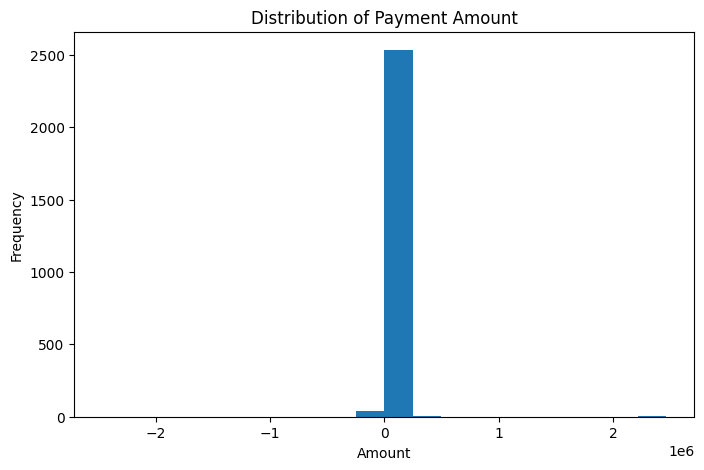

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
plt.hist(df['Amount'].dropna(), bins=20)
plt.title("Distribution of Payment Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

## Interpretation of your above chart

A histogram is used to show the distribution of a numerical variable.
In this analysis, it displays how the payment amounts (Amount) are distributed across all transactions.
The X-axis represents the payment amount, and the Y-axis represents the number of transactions (frequency).

The chart shows whether most payments are small, medium, or large.

Feature analyzed: Amount
Visualization: Histogram

The distribution of payment values.
The range where most payments occur.
Overall spending pattern in the dataset.



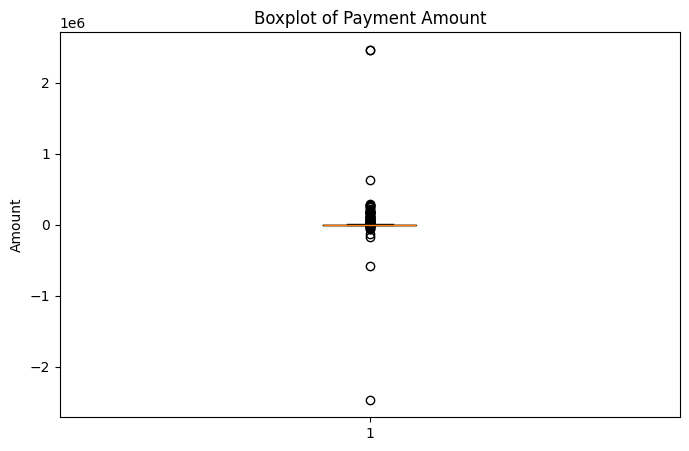

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Amount'].dropna())
plt.title("Boxplot of Payment Amount")
plt.ylabel("Amount")
plt.show()

## Interpretation of your above chart

A boxplot is used to visualize the distribution of numerical data and detect outliers.
In this analysis, the boxplot represents the Amount column.

The chart shows how payment amounts are spread across the dataset.
It helps identify whether most transactions are clustered within a particular range or widely spread.

Feature analyzed: Amount
Visualization: Boxplot

Identify the median payment amount.
Detect outliers, which may indicate unusually large transactions.
Assess whether the payment data is evenly distributed or skewed.

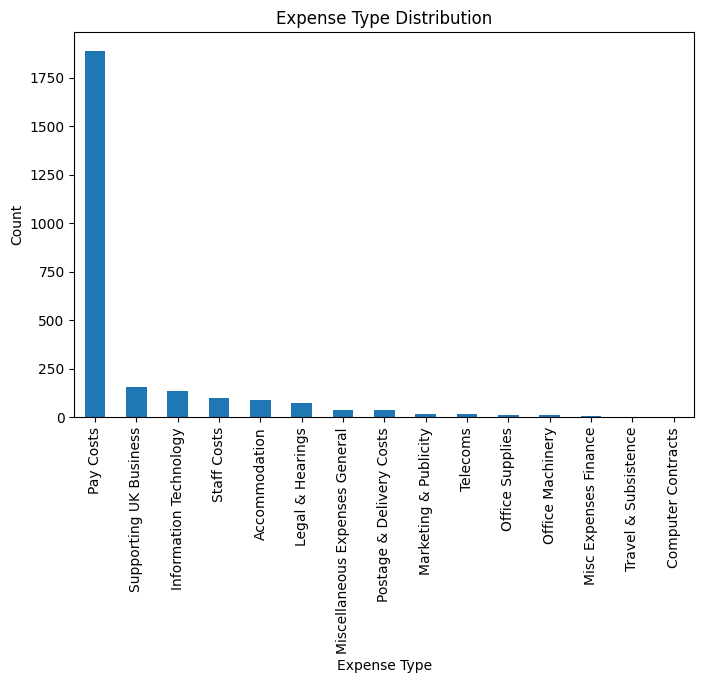

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
df['Expense type'].value_counts().plot(kind='bar')
plt.title("Expense Type Distribution")
plt.xlabel("Expense Type")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

## Interpretation of your above chart

A bar chart is used to compare the number of transactions across different departments.
The X-axis represents the Expense type.
The Y-axis represents the count of transactions recorded for each department.

Departments with taller bars have recorded more financial transactions, while shorter bars indicate fewer transactions.
This helps identify which departments are more active in terms of spending or financial operations.

Feature analyzed: Department family
Visualization: Bar Chart (using value_counts())

Compare the number of transactions across departments.
Identify the departments with the highest and lowest transaction volumes.
Understand which departments contribute most to the organization's financial activities.

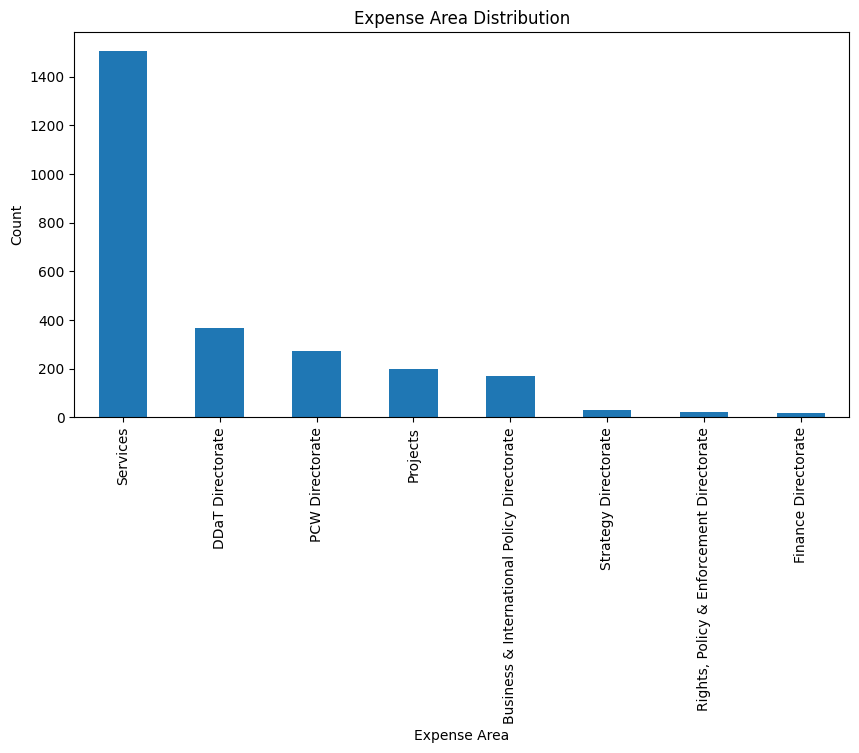

In [ ]:
plt.figure(figsize=(10,5))
df['Expense area'].value_counts().plot(kind='bar')
plt.title("Expense Area Distribution")
plt.xlabel("Expense Area")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

## Interpretation of your above chart

A bar chart was used to display the number of transactions for each Expense Area.
The X-axis represents the different Expense Areas, and the Y-axis represents the count of transactions in each area.
This chart compares how frequently expenses occur across different operational areas.

The chart shows which expense areas have the highest and lowest number of transactions.
Expense areas with taller bars indicate more financial activity, while shorter bars indicate fewer transactions.
It helps identify the operational areas where spending activities are most frequent.

Feature analyzed: Expense area
Visualization: Bar Chart
Identify the operational areas with the highest transaction activity.
Compare transaction volumes between different expense areas.
Understand where most expenses are being recorded.

object


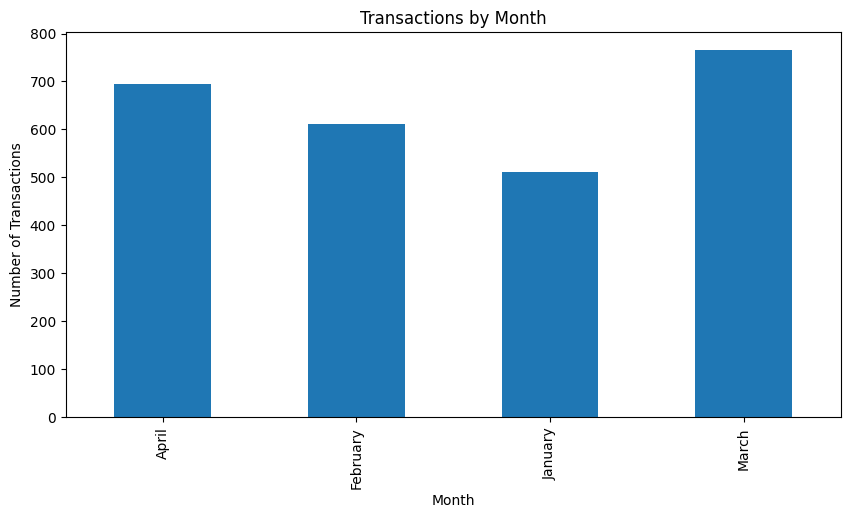

In [ ]:
import matplotlib.pyplot as plt
print(df['Date'].dtype)
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
plt.figure(figsize=(10,5))
df['Month'].value_counts().sort_index().plot(kind='bar')
plt.title("Transactions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()


## Interpretation of your above chart

A bar chart was created to show the number of transactions recorded in each month.
The Month was extracted from the Date column.
The X-axis represents the months, and the Y-axis represents the number of transactions.

The chart shows how transaction activity changes from month to month.
Months with taller bars have more recorded transactions, indicating higher financial activity.
Months with shorter bars have fewer transactions, indicating lower financial activity.
This helps identify periods of increased or decreased business spending.

Features analyzed: Date (from which the Month was derived)
Derived Feature: Month
Visualization: Bar Chart

Compare the number of transactions across different months.
Identify the months with the highest and lowest financial activity.
Understand monthly transaction trends.

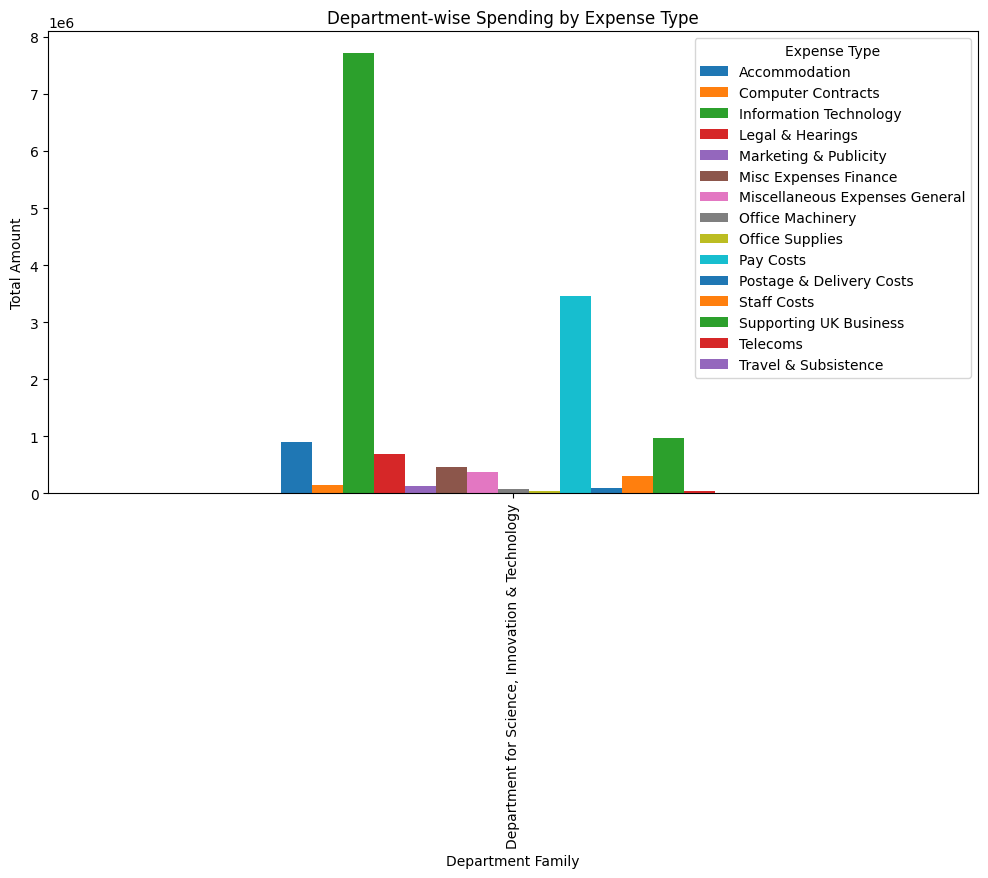

In [ ]:
grouped = df.groupby(['Department family', 'Expense type'])['Amount'].sum().unstack()

grouped.plot(kind='bar', figsize=(12,6))
plt.title("Department-wise Spending by Expense Type")
plt.xlabel("Department Family")
plt.ylabel("Total Amount")
plt.legend(title="Expense Type")
plt.show()

A grouped bar chart compares the total amount spent by each department across different expense types.
The X-axis represents the Department Family.
The Y-axis represents the Total Amount spent.
Different colored bars represent different Expense Types.

The chart shows how spending varies across departments and expense categories.
It helps identify:
Which departments spend the most.
Which expense types contribute the most to departmental spending.
Whether spending patterns differ between departments.

Feature 1: Department family
Feature 2: Expense type
Feature 3: Amount
Aggregation: sum()
Visualization: Grouped Bar Chart

Compare spending across different departments.
Identify the highest spending departments.
Understand which expense types contribute most to each department's expenditure.

In [ ]:
pivot = pd.pivot_table(
    df,
    values='Amount',
    index='Department family',
    columns='Expense type',
    aggfunc='sum',
    fill_value=0
)

print(pivot)

Expense type                                     Accommodation  \
Department family                                                
Department for Science, Innovation & Technology         903589   

Expense type                                     Computer Contracts  \
Department family                                                     
Department for Science, Innovation & Technology              141943   

Expense type                                     Information Technology  \
Department family                                                         
Department for Science, Innovation & Technology                 7710642   

Expense type                                     Legal & Hearings  \
Department family                                                   
Department for Science, Innovation & Technology            690060   

Expense type                                     Marketing & Publicity  \
Department family                                                        
Depar

A pivot table summarizes data by grouping it based on rows and columns.
In this analysis:
Rows (Index): Department family
Columns: Expense type
Values: Amount
Aggregation: sum()

The pivot table shows how spending is distributed across departments and expense categories.
It helps identify:
Which department has the highest expenditure.
Which expense type contributes the most to each department's spending.
Spending patterns across the organization.

Feature 1: Department family
Feature 2: Expense type
Feature 3: Amount
Aggregation Function: sum()
Compare total spending across departments.
Compare spending across different expense types.
Identify high-spending departments and categories.

In [ ]:
df['Month'] = df['Date'].dt.month_name()

In [ ]:
monthly_amount = df.groupby('Month')['Amount'].sum()

In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_amount = monthly_amount.reindex(month_order)

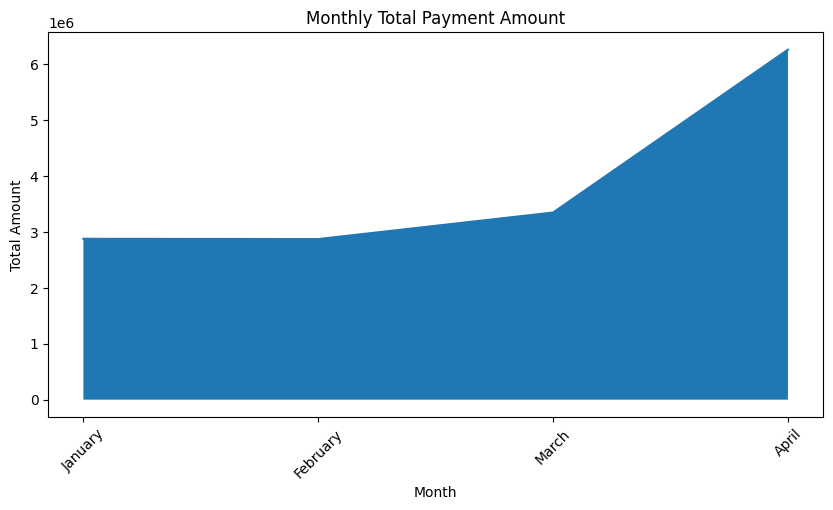

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.fill_between(monthly_amount.index, monthly_amount.values)

plt.plot(monthly_amount.index, monthly_amount.values)

plt.title("Monthly Total Payment Amount")
plt.xlabel("Month")
plt.ylabel("Total Amount")

plt.xticks(rotation=45)

plt.show()

An Area Chart displays the trend of total payment amounts over time.
The X-axis represents the Month.
The Y-axis represents the Total Payment Amount.

The chart shows how the organization's total spending changes from month to month.
Peaks indicate months with higher expenditure.
Lower areas indicate months with reduced spending.

Feature 1: Date (converted to Month)
Feature 2: Amount
Aggregation: sum() (total monthly payments)
Visualization: Area Chart
Track monthly expenditure trends.
Identify months with the highest and lowest spending.
Compare financial activity across different months.